In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
PROJECT_ROOT = Path("..")

EVENTS_PATH = PROJECT_ROOT / "data/interim/dashboard_events.parquet"
FIGURES_DIR = PROJECT_ROOT / "reports/figures"
METRICS_DIR = PROJECT_ROOT / "reports/metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
events = pd.read_parquet(EVENTS_PATH)

events["timestamp"] = pd.to_datetime(events["timestamp"], format="mixed")
events["date"] = events["timestamp"].dt.floor("D")
print("Rows:", len(events))
print("Date range:", events["date"].min(), "to", events["date"].max())
print("Unique users:", events["user"].nunique())
print("Unique dashboards:", events["dashboard_id"].nunique())
events

Rows: 69152
Date range: 2018-08-09 00:00:00 to 2021-01-10 00:00:00
Unique users: 245
Unique dashboards: 28


,timestamp,user,method,endpoint,status,dashboard_id,path,browser,browser_platform,browser_version,date
0,2018-08-09 14:00:00.000000,b1fababf379ab3d8@project-a.com,GET,dashboards.view_dashboard,200,marketing-overview,/dashboards/marketing-overview,chrome,macos,67.0.3396.99,2018-08-09
1,2018-08-09 14:00:00.000000,b1fababf379ab3d8@project-a.com,GET,dashboards.view_dashboard,200,marketing-overview,/dashboards/marketing-overview,chrome,macos,67.0.3396.99,2018-08-09
2,2018-08-09 14:00:00.000000,b1fababf379ab3d8@project-a.com,GET,dashboards.view_dashboard,200,marketing-overview,/dashboards/marketing-overview,chrome,macos,67.0.3396.99,2018-08-09
3,2018-08-09 14:00:00.000000,b1fababf379ab3d8@project-a.com,GET,dashboards.view_dashboard,200,marketing-overview,/dashboards/marketing-overview,chrome,macos,67.0.3396.99,2018-08-09
4,2018-08-09 14:00:00.000000,b1fababf379ab3d8@project-a.com,GET,dashboards.view_dashboard,200,marketing-overview,/dashboards/marketing-overview,chrome,macos,67.0.3396.99,2018-08-09
...,...,...,...,...,...,...,...,...,...,...,...
69147,2021-01-10 14:18:03.587892,9942c672b9354771@lampenwelt.de,GET,dashboards.view_dashboard,200,revenue-factura,/dashboards/revenue-factura,chrome,windows,87.0.4280.88,2021-01-10
69148,2021-01-10 14:19:02.411386,9942c672b9354771@lampenwelt.de,GET,dashboards.view_dashboard,200,sales-comparison,/dashboards/sales-comparison,chrome,windows,87.0.4280.88,2021-01-10
69149,2021-01-10 16:00:06.753419,91ec8c4f7243bd8d@lampenwelt.de,GET,dashboards.view_dashboard,200,weekly-sales-comparison,/dashboards/weekly-sales-comparison,chrome,windows,87.0.4280.88,2021-01-10
69150,2021-01-10 17:02:41.778970,27707832861149d0@lampenwelt.de,GET,dashboards.view_dashboard,200,sales-comparison,/dashboards/sales-comparison,chrome,macos,88.0.4324.50,2021-01-10


In [6]:
daily_views = (
    events
    .groupby("date")
    .size()
    .reset_index(name="y")
    .rename(columns={"date": "ds"})
    .sort_values("ds")
)

full_dates = pd.DataFrame({
    "ds": pd.date_range(
        start=daily_views["ds"].min(),
        end=daily_views["ds"].max(),
        freq="D"
    )
})

prophet_df = (
    full_dates
    .merge(daily_views, on="ds", how="left")
    .fillna({"y": 0})
)

prophet_df["y"] = prophet_df["y"].astype(int)

prophet_df

,ds,y
0,2018-08-09,30
1,2018-08-10,29
2,2018-08-11,0
3,2018-08-12,1
4,2018-08-13,31
...,...,...
881,2021-01-06,195
882,2021-01-07,149
883,2021-01-08,175
884,2021-01-09,13


In [7]:
fig = px.line(
    prophet_df,
    x="ds",
    y="y",
    title="Daily Dashboard Views",
    labels={
        "ds": "Date",
        "y": "Daily dashboard views",
    },
)

fig.update_layout(template="plotly_white", height=500)
fig.show()

In [8]:
validation_days = 14

train_df = prophet_df.iloc[:-validation_days].copy()
valid_df = prophet_df.iloc[-validation_days:].copy()

print("Train:", train_df["ds"].min(), "to", train_df["ds"].max())
print("Validation:", valid_df["ds"].min(), "to", valid_df["ds"].max())
print("Train rows:", len(train_df))
print("Validation rows:", len(valid_df))

Train: 2018-08-09 00:00:00 to 2020-12-27 00:00:00
Validation: 2020-12-28 00:00:00 to 2021-01-10 00:00:00
Train rows: 872
Validation rows: 14


In [11]:
def calculate_metrics(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    epsilon = 1e-8
    smape = np.mean(
        2 * np.abs(actual - predicted) /
        (np.abs(actual) + np.abs(predicted) + epsilon)
    )

    return {
        "mae": mae,
        "rmse": rmse,
    }

# BASELINE

In [12]:
last_value = train_df["y"].iloc[-1]

naive_eval = valid_df.copy()
naive_eval["yhat"] = last_value

naive_metrics = calculate_metrics(
    naive_eval["y"],
    naive_eval["yhat"],
)

naive_metrics["model"] = "naive_last_value"
naive_metrics

{'mae': 82.14285714285714,
 'rmse': np.float64(109.79656512972396),
 'model': 'naive_last_value'}

In [15]:
prophet_options = [
    {
        "model": "prophet_basic",
        "yearly_seasonality": True,
        "weekly_seasonality": True,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.05,
    },
    {
        "model": "prophet_multiplicative",
        "yearly_seasonality": True,
        "weekly_seasonality": True,
        "seasonality_mode": "multiplicative",
        "changepoint_prior_scale": 0.05,
    },
    {
        "model": "prophet_conservative_trend",
        "yearly_seasonality": True,
        "weekly_seasonality": True,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.01,
    },
    {
        "model": "prophet_flexible_trend",
        "yearly_seasonality": True,
        "weekly_seasonality": True,
        "seasonality_mode": "additive",
        "changepoint_prior_scale": 0.10,
    },
]

In [16]:
results = []
forecasts = {}

results.append(naive_metrics)
forecasts["naive_last_value"] = naive_eval[["ds", "y", "yhat"]].copy()

for params in prophet_options:
    model_name = params["model"]

    model = Prophet(
        yearly_seasonality=params["yearly_seasonality"],
        weekly_seasonality=params["weekly_seasonality"],
        daily_seasonality=False,
        seasonality_mode=params["seasonality_mode"],
        changepoint_prior_scale=params["changepoint_prior_scale"],
        interval_width=0.90,
    )

    model.fit(train_df)

    future = model.make_future_dataframe(
        periods=validation_days,
        freq="D",
    )

    forecast = model.predict(future)

    valid_forecast = forecast[forecast["ds"].isin(valid_df["ds"])][
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ]

    eval_df = valid_df.merge(valid_forecast, on="ds", how="left")

    metrics = calculate_metrics(
        eval_df["y"],
        eval_df["yhat"],
    )

    coverage = (
        (eval_df["y"] >= eval_df["yhat_lower"]) &
        (eval_df["y"] <= eval_df["yhat_upper"])
    ).mean()

    metrics["model"] = model_name
    metrics["coverage"] = coverage

    results.append(metrics)
    forecasts[model_name] = eval_df.copy()

18:52:14 - cmdstanpy - INFO - Chain [1] start processing
18:52:15 - cmdstanpy - INFO - Chain [1] done processing
18:52:15 - cmdstanpy - INFO - Chain [1] start processing
18:52:15 - cmdstanpy - INFO - Chain [1] done processing
18:52:15 - cmdstanpy - INFO - Chain [1] start processing
18:52:15 - cmdstanpy - INFO - Chain [1] done processing
18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
results

[{'mae': 82.14285714285714,
  'rmse': np.float64(109.79656512972396),
  'model': 'naive_last_value',
  'coverage': nan},
 {'mae': 47.30645816541369,
  'rmse': np.float64(52.746300321531834),
  'model': 'prophet_basic',
  'coverage': np.float64(0.7142857142857143)},
 {'mae': 45.82433445101532,
  'rmse': np.float64(50.0035042847959),
  'model': 'prophet_multiplicative',
  'coverage': np.float64(0.35714285714285715)},
 {'mae': 48.84980313764288,
  'rmse': np.float64(55.22086516845397),
  'model': 'prophet_conservative_trend',
  'coverage': np.float64(0.7142857142857143)},
 {'mae': 47.667523275956135,
  'rmse': np.float64(53.273839478901856),
  'model': 'prophet_flexible_trend',
  'coverage': np.float64(0.7142857142857143)}]

In [20]:
results_df = pd.DataFrame(results)

results_df = results_df[["model", "mae", "rmse",  "coverage"]]

results_df = results_df.sort_values("mae").reset_index(drop=True)

results_df

,model,mae,rmse,coverage
0,prophet_multiplicative,45.824334,50.003504,0.357143
1,prophet_basic,47.306458,52.746300,0.714286
2,prophet_flexible_trend,47.667523,53.273839,0.714286
3,prophet_conservative_trend,48.849803,55.220865,0.714286
4,naive_last_value,82.142857,109.796565,NaN


# Best model

In [22]:
best_model_name = results_df.iloc[0]["model"]

print("Best model by MAE:", best_model_name)

best_eval_df = forecasts[best_model_name]
best_eval_df

Best model by MAE: prophet_multiplicative


,ds,y,yhat,yhat_lower,yhat_upper
0,2020-12-28,88,149.833846,102.932587,193.104766
1,2020-12-29,81,127.699706,83.519980,171.475098
2,2020-12-30,69,122.407597,80.195108,163.025458
3,2020-12-31,34,109.161463,64.227505,150.835471
4,2021-01-01,13,95.097869,53.428123,137.847950
5,2021-01-02,18,-36.503825,-79.599445,7.003228
6,2021-01-03,18,-30.825617,-72.153492,9.578031
7,2021-01-04,194,167.617980,127.211649,209.018161
8,2021-01-05,189,148.502095,104.498857,192.154012
9,2021-01-06,195,145.872824,103.707849,186.810615


In [23]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=train_df.tail(90)["ds"],
        y=train_df.tail(90)["y"],
        mode="lines",
        name="Train actual",
    )
)

fig.add_trace(
    go.Scatter(
        x=valid_df["ds"],
        y=valid_df["y"],
        mode="lines+markers",
        name="Validation actual",
    )
)

fig.add_trace(
    go.Scatter(
        x=best_eval_df["ds"],
        y=best_eval_df["yhat"],
        mode="lines+markers",
        name=f"Forecast: {best_model_name}",
    )
)

if "yhat_upper" in best_eval_df.columns:
    fig.add_trace(
        go.Scatter(
            x=pd.concat([best_eval_df["ds"], best_eval_df["ds"][::-1]]),
            y=pd.concat([
                best_eval_df["yhat_upper"],
                best_eval_df["yhat_lower"][::-1],
            ]),
            fill="toself",
            line=dict(width=0),
            name="90% prediction interval",
            opacity=0.2,
        )
    )

fig.update_layout(
    title=f"MVP Validation: {best_model_name}",
    template="plotly_white",
    height=550,
    xaxis_title="Date",
    yaxis_title="Daily dashboard views",
)

fig.show()

fig.write_html(FIGURES_DIR / "mvp_best_model_validation.html")

In [24]:
best_model_summary = {
    "best_model": best_model_name,
    "selection_metric": "mae",
    "validation_days": validation_days,
    "train_start": str(train_df["ds"].min().date()),
    "train_end": str(train_df["ds"].max().date()),
    "validation_start": str(valid_df["ds"].min().date()),
    "validation_end": str(valid_df["ds"].max().date()),
    "metrics": results_df.iloc[0].to_dict(),
}

best_summary_path = METRICS_DIR / "mvp_best_model_summary.json"

with open(best_summary_path, "w", encoding="utf-8") as f:
    json.dump(best_model_summary, f, indent=4)

best_model_summary

{'best_model': 'prophet_multiplicative',
 'selection_metric': 'mae',
 'validation_days': 14,
 'train_start': '2018-08-09',
 'train_end': '2020-12-27',
 'validation_start': '2020-12-28',
 'validation_end': '2021-01-10',
 'metrics': {'model': 'prophet_multiplicative',
  'mae': 45.82433445101532,
  'rmse': 50.0035042847959,
  'coverage': 0.35714285714285715}}

18:57:05 - cmdstanpy - INFO - Chain [1] start processing
18:57:05 - cmdstanpy - INFO - Chain [1] done processing


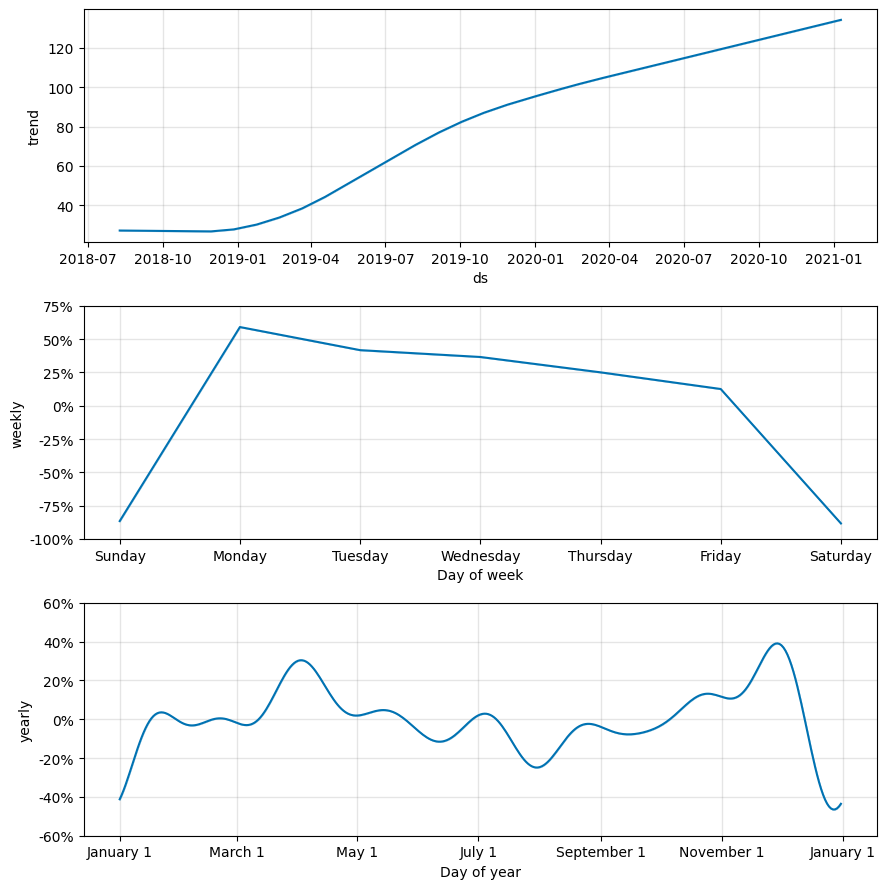

In [25]:
best_params = next(
    item for item in prophet_options
    if item["model"] == best_model_name
)

best_model = Prophet(
    yearly_seasonality=best_params["yearly_seasonality"],
    weekly_seasonality=best_params["weekly_seasonality"],
    daily_seasonality=False,
    seasonality_mode=best_params["seasonality_mode"],
    changepoint_prior_scale=best_params["changepoint_prior_scale"],
    interval_width=0.90,
)

best_model.fit(train_df)

future = best_model.make_future_dataframe(periods=validation_days, freq="D")
forecast = best_model.predict(future)

components = best_model.plot_components(forecast)